In [5]:
# Wykresy diagnostyczne dla pelnego skanu po t0 (22 stacje) z
# 20260820a.ipynb - CELOWO w OSOBNYM notebooku, zeby wczytywanie/rysowanie
# nigdy nie wymagalo (przypadkowego ani celowego) ponownego przejscia przez
# 20260820a.ipynb komorke 4 (kosztowny skan, ~2h). Ten notebook NIE zalezy
# od zadnej zmiennej z 20260820a.ipynb - wczytuje WYLACZNIE juz zapisane
# pliki z results/ (t0_scan_{stacja}_d{d}.csv, 44 pliki, ~66MB), tworzone
# przez `run_t0_scan_parallel` (mc_parallel.py) w 20260820a.ipynb.
#
# Historia (2026-08-20): Maciek odpalil 20260820a.ipynb od gory do dolu po
# tym, jak te wykresy zostaly dopisane jako komorki 7-10 NA KONCU tamtego
# notebooka - "od gory do dolu" ponownie przeszlo przez komorke 4
# (kosztowny skan) i zostalo przerwane. Sprawdzone (2026-08-20, po
# przerwaniu): WSZYSTKIE 44 pliki wynikow maja mtime i liczbe wierszy
# (15944 = naglowek + 15943) identyczne jak po pierwszym, udanym uruchomieniu
# - przerwanie zlapalo notebook w trakcie PIERWSZEJ iteracji petli (mosc,
# d=1, ktora nigdy sie nie skonczyla), WIEC ZADEN plik wynikowy nie zostal
# nadpisany ani uszkodzony (funkcja zapisuje CSV dopiero PO ukonczeniu
# calego skanu dla danej pary stacja/d - zapis jest wiec atomowy per
# stacja/d, nie ma czesciowych/ucietych plikow). Dane sa bezpieczne. Zeby
# to sie nie powtorzylo, wykresy przeniesione tutaj, do notebooka ktory
# NIGDY nie zawiera komorki 4 z 20260820a.ipynb.
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

RESULTS_DIR = "../results"

scan_files = sorted(glob.glob(f"{RESULTS_DIR}/t0_scan_*_d*.csv"))
scan_files = [f for f in scan_files if "summary" not in f]
STATIONS_PLOT = sorted({f.split("t0_scan_")[1].rsplit("_d", 1)[0] for f in scan_files})
D_VALUES = sorted({int(f.rsplit("_d", 1)[1].replace(".csv", "")) for f in scan_files})
print(f"Znaleziono zapisane skany dla {len(STATIONS_PLOT)} stacji, d w {D_VALUES}: {STATIONS_PLOT}")

full_scans = {}  # (stacja, d) -> DataFrame z kolumnami t0, PPDF
for station in STATIONS_PLOT:
    for d in D_VALUES:
        path = f"{RESULTS_DIR}/t0_scan_{station}_d{d}.csv"
        full_scans[(station, d)] = pd.read_csv(path, usecols=["t0", "PPDF"], parse_dates=["t0"])

n_rows = len(next(iter(full_scans.values())))
print(f"Wczytano {len(full_scans)} pelnych skanow, po {n_rows} wierszy (kandydatow t0) kazdy")

# Referencyjne t0 z artykulu, do zaznaczenia na wykresach (patrz 20260819.txt
# pkt 6, ARTICLE_REF w 20260819a.ipynb).
ARTICLE_T0_MOSC = pd.Timestamp("2013-11-14")
ARTICLE_T0_OULU = pd.Timestamp("2014-01-04")


Znaleziono zapisane skany dla 22 stacji, d w [1, 5]: ['aatb', 'apty', 'athn', 'fsmt', 'hrms', 'invk', 'jung', 'jung1', 'lmks', 'mcrl', 'mosc', 'mxco', 'nain', 'nanm', 'newk', 'oulu', 'psnm', 'pwnk', 'sopb', 'sopo', 'tera', 'thul']
Wczytano 44 pelnych skanow, po 15943 wierszy (kandydatow t0) kazdy


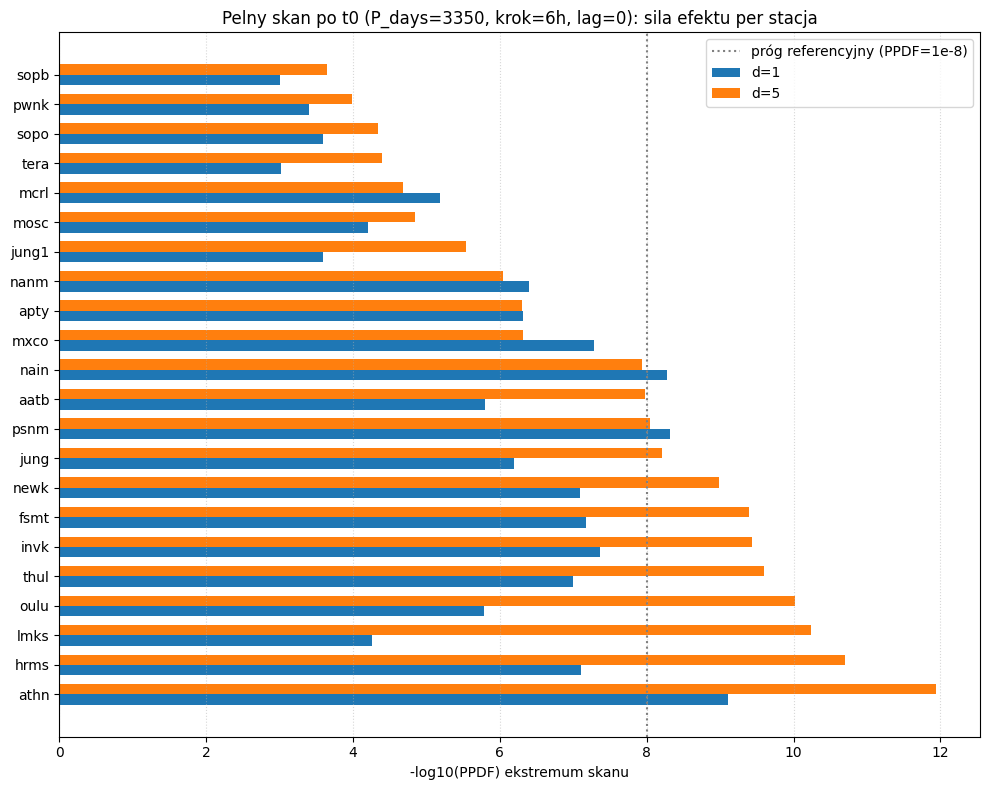

In [6]:
# Wykres podsumowujacy: -log10(PPDF) ekstremum per stacja, d=1/d=5 obok
# siebie, z linia progu referencyjnego. Wersja DOSTEPNA (ten notebook, bez
# zaleznosci od kosztownej komorki skanu w 20260820a.ipynb) - etykiety
# celowo neutralne (bez nazwisk), wykres przeznaczony do udostepniania
# zespolowi. Nadpisuje ten sam plik co oryginal w 20260820a.ipynb komorka 6
# (results/t0_scan_22stations_summary_plot.png), wiec wersja z tego
# notebooka staje sie kanoniczna.
REFERENCE_LOG10_PPDF = -8

summary_saved = pd.read_csv(f"{RESULTS_DIR}/t0_scan_22stations_summary.csv", parse_dates=["t0_best"])
pivot = summary_saved.pivot(index="station", columns="d", values="log10_PPDF")
order_col = 5 if 5 in pivot.columns else pivot.columns[0]
order = pivot[order_col].sort_values().index
pivot = pivot.loc[order]

fig, ax = plt.subplots(figsize=(10, 8))
y = np.arange(len(pivot))
width = 0.35
for i, d in enumerate(D_VALUES):
    if d not in pivot.columns:
        continue
    ax.barh(y + (i - 0.5) * width, -pivot[d], height=width, label=f"d={d}")
ax.axvline(-REFERENCE_LOG10_PPDF, color="gray", ls=":", label="próg referencyjny (PPDF=1e-8)")
ax.set_yticks(y)
ax.set_yticklabels(pivot.index)
ax.set_xlabel("-log10(PPDF) ekstremum skanu")
ax.set_title("Pelny skan po t0 (P_days=3350, krok=6h, lag=0): sila efektu per stacja")
ax.legend()
ax.grid(ls=":", alpha=0.5, axis="x")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/t0_scan_22stations_summary_plot.png", dpi=120)
plt.show()


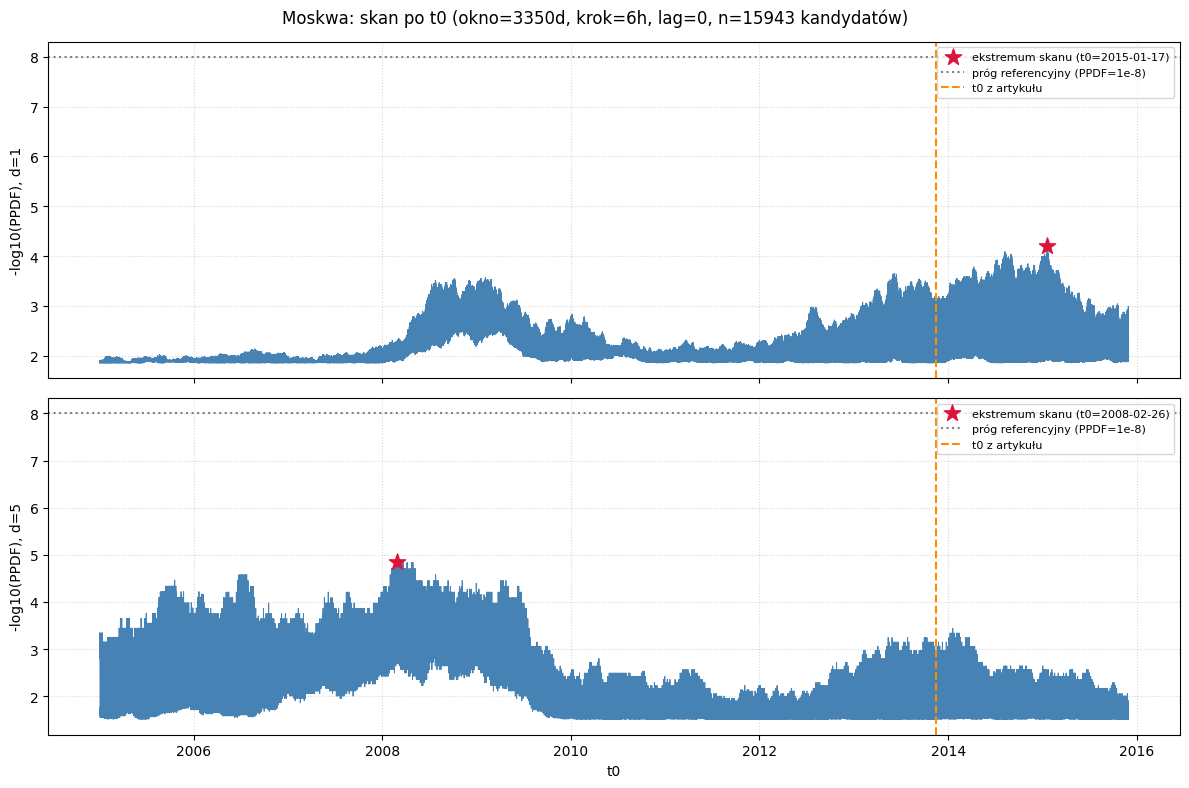

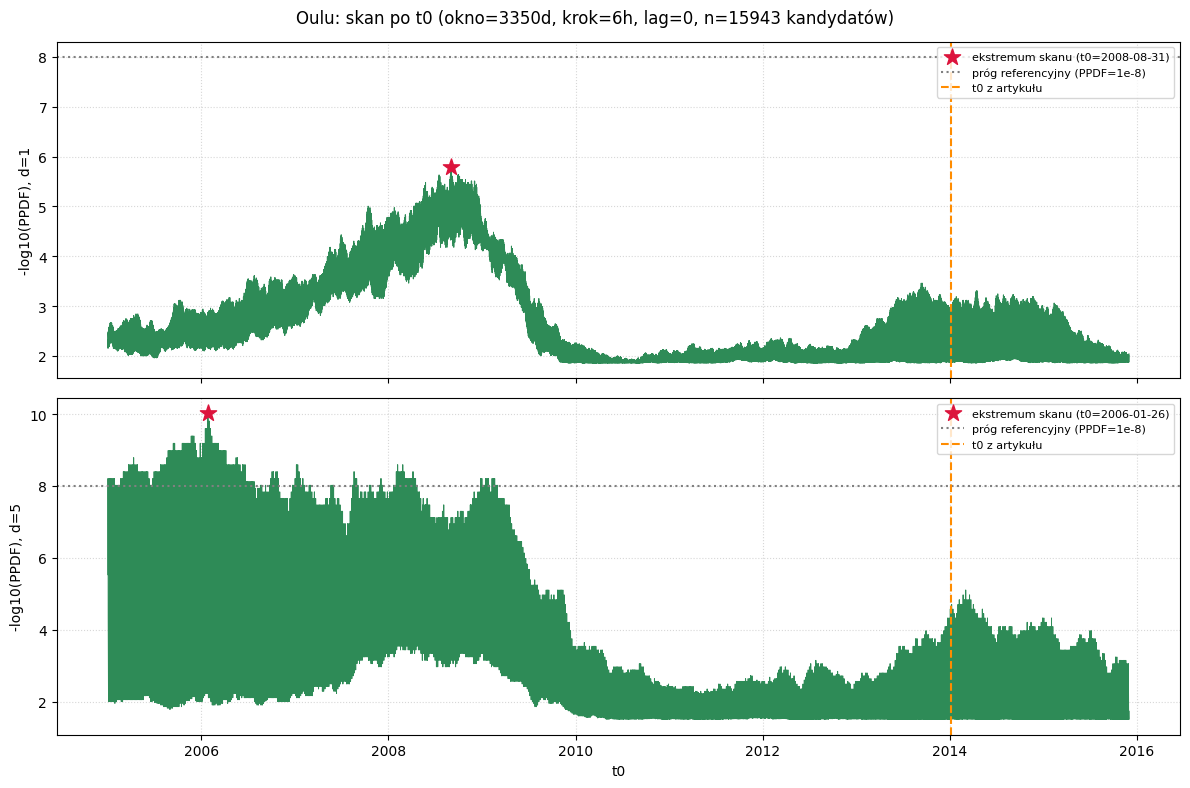

In [7]:
# Wykresy szczegolowe PPDF vs t0 dla Moskwy i Oulu (jak w 20260819a.ipynb
# komorki 7-8), wersja DOSTEPNA - zbudowana z full_scans (komorka 0
# powyzej), bez zaleznosci od 20260819a.ipynb. Etykiety celowo neutralne
# (bez nazwisk) - wykres przeznaczony do udostepniania zespolowi. Nadpisuje
# te same pliki co oryginal (results/t0_scan_{mosc,oulu}_plot.png).
REF_STATIONS = {"mosc": ("Moskwa", "steelblue", ARTICLE_T0_MOSC),
                 "oulu": ("Oulu", "seagreen", ARTICLE_T0_OULU)}

for station, (label, color, article_t0) in REF_STATIONS.items():
    fig, axes = plt.subplots(len(D_VALUES), 1, figsize=(12, 8), sharex=True)
    for ax, d in zip(np.atleast_1d(axes), D_VALUES):
        df_scan = full_scans[(station, d)]
        ax.plot(df_scan["t0"], -np.log10(df_scan["PPDF"]), lw=0.7, color=color)
        best = df_scan.loc[df_scan["PPDF"].idxmin()]
        ax.scatter([best["t0"]], [-np.log10(best["PPDF"])], color="crimson", zorder=5,
                   marker="*", s=150, label=f"ekstremum skanu (t0={pd.Timestamp(best['t0']).date()})")
        ax.axhline(-REFERENCE_LOG10_PPDF, color="gray", ls=":", label="próg referencyjny (PPDF=1e-8)")
        ax.axvline(article_t0, color="darkorange", ls="--", label="t0 z artykułu")
        ax.set_ylabel(f"-log10(PPDF), d={d}")
        ax.legend(loc="upper right", fontsize=8)
        ax.grid(ls=":", alpha=0.5)
    axes[-1].set_xlabel("t0")
    fig.suptitle(f"{label}: skan po t0 (okno=3350d, krok=6h, lag=0, n={len(df_scan)} kandydatów)")
    fig.tight_layout()
    fig.savefig(f"{RESULTS_DIR}/t0_scan_{station}_plot.png", dpi=120)
    plt.show()


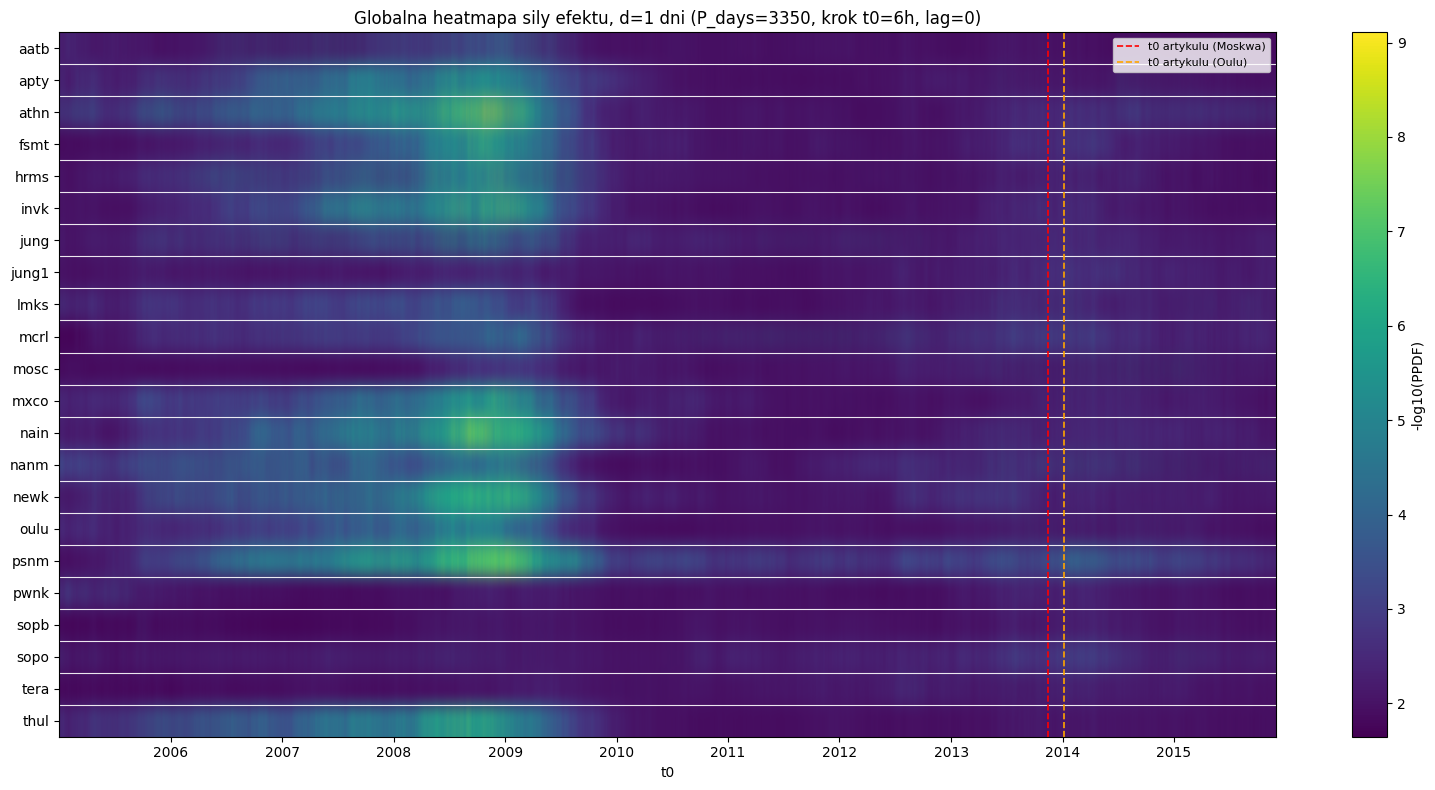

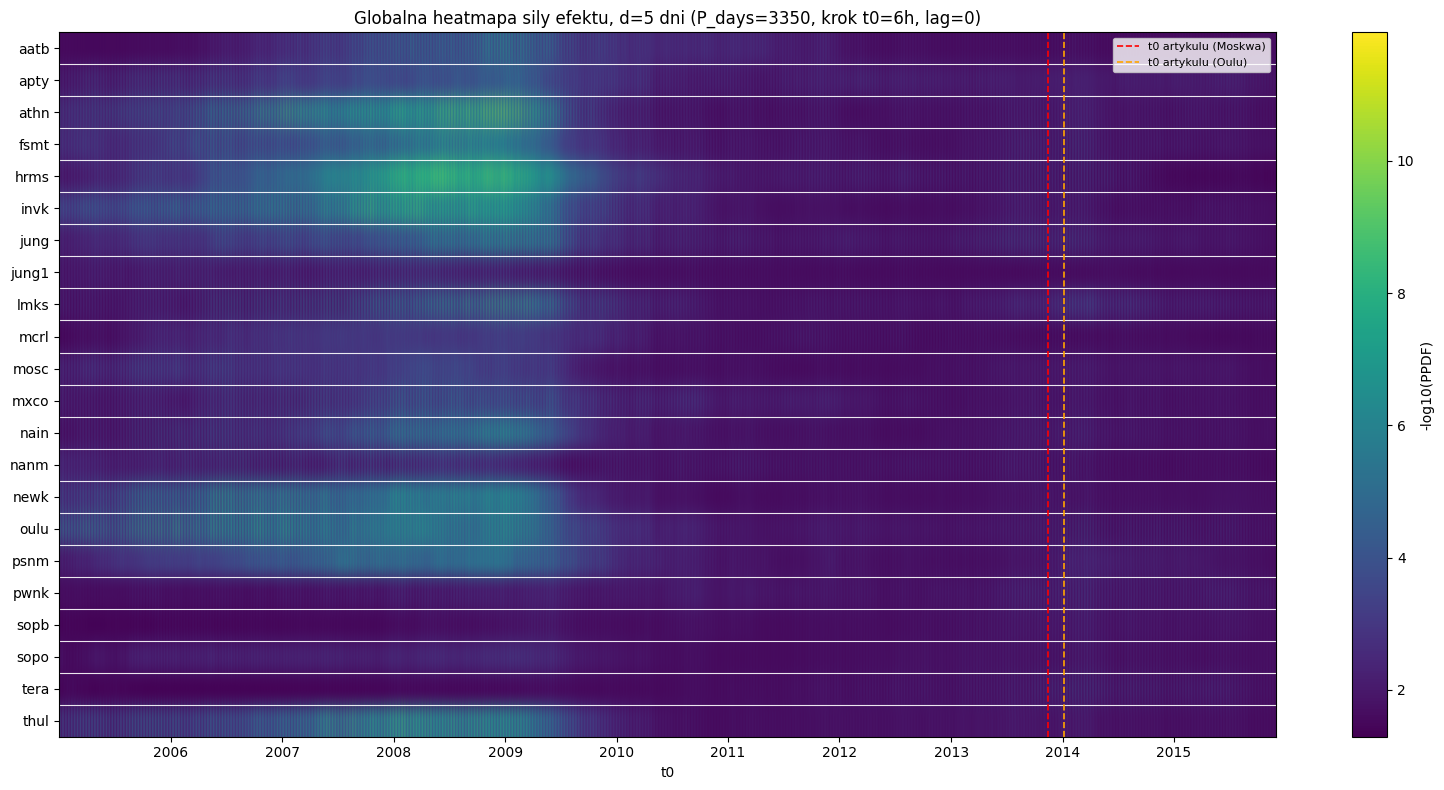

In [8]:
# Globalna heatmapa "parametrow efektu" - DOKLADNIE to, o co prosil Homola
# (zrodla/Maciej Flaga Praktyki 2026.txt, komentarz [u]: "Cennym wnioskiem
# mozgloby byc zrobienie globalnej heatmapy parametrow efektu, moze w
# optymalnym t0 wyszloby cos w rodzaju sezonowosci?"). Os X = kazdy z
# kandydatow t0, os Y = stacja, kolor = -log10(PPDF) (definicja "sily
# efektu" wg Homoli, kom. [k]). To pokazuje CALY skan, nie tylko ekstremum -
# widac na tym m.in. klaster 2006-2009 (patrz interpretacja w dzienniku
# 20260820.txt pkt 9) jako pionowy pas jasnych kolorow wspolny dla wielu
# stacji naraz.
def build_heatmap_matrix(d):
    t0_ref = full_scans[(STATIONS_PLOT[0], d)]["t0"].to_numpy()
    mat = np.full((len(STATIONS_PLOT), len(t0_ref)), np.nan)
    for i, station in enumerate(STATIONS_PLOT):
        ppdf = full_scans[(station, d)]["PPDF"].to_numpy()
        with np.errstate(divide="ignore"):
            mat[i] = -np.log10(np.clip(ppdf, 1e-300, None))
    return t0_ref, mat

for d in D_VALUES:
    t0_ref, mat = build_heatmap_matrix(d)
    fig, ax = plt.subplots(figsize=(16, 8))
    im = ax.imshow(
        mat, aspect="auto", cmap="viridis",
        extent=[mdates.date2num(t0_ref[0]), mdates.date2num(t0_ref[-1]), len(STATIONS_PLOT) - 0.5, -0.5],
    )
    ax.xaxis_date()
    ax.set_yticks(range(len(STATIONS_PLOT)))
    ax.set_yticklabels(STATIONS_PLOT)
    # Wyrazne linie oddzielajace wiersze (stacje) - bez tego przy 22
    # stacjach na wspolnej heatmapie wszystko sie wizualnie zlewa.
    for i in range(1, len(STATIONS_PLOT)):
        ax.axhline(i - 0.5, color="white", lw=0.8, alpha=0.9)
    ax.set_ylim(len(STATIONS_PLOT) - 0.5, -0.5)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("-log10(PPDF)")
    ax.axvline(ARTICLE_T0_MOSC, color="red", ls="--", lw=1.2, label="t0 artykulu (Moskwa)")
    ax.axvline(ARTICLE_T0_OULU, color="orange", ls="--", lw=1.2, label="t0 artykulu (Oulu)")
    ax.set_xlabel("t0")
    ax.set_title(f"Globalna heatmapa sily efektu, d={d} dni (P_days=3350, krok t0=6h, lag=0)")
    ax.legend(loc="upper right", fontsize=8)
    fig.tight_layout()
    fig.savefig(f"../results/t0_scan_heatmap_d{d}.png", dpi=120)
    plt.show()


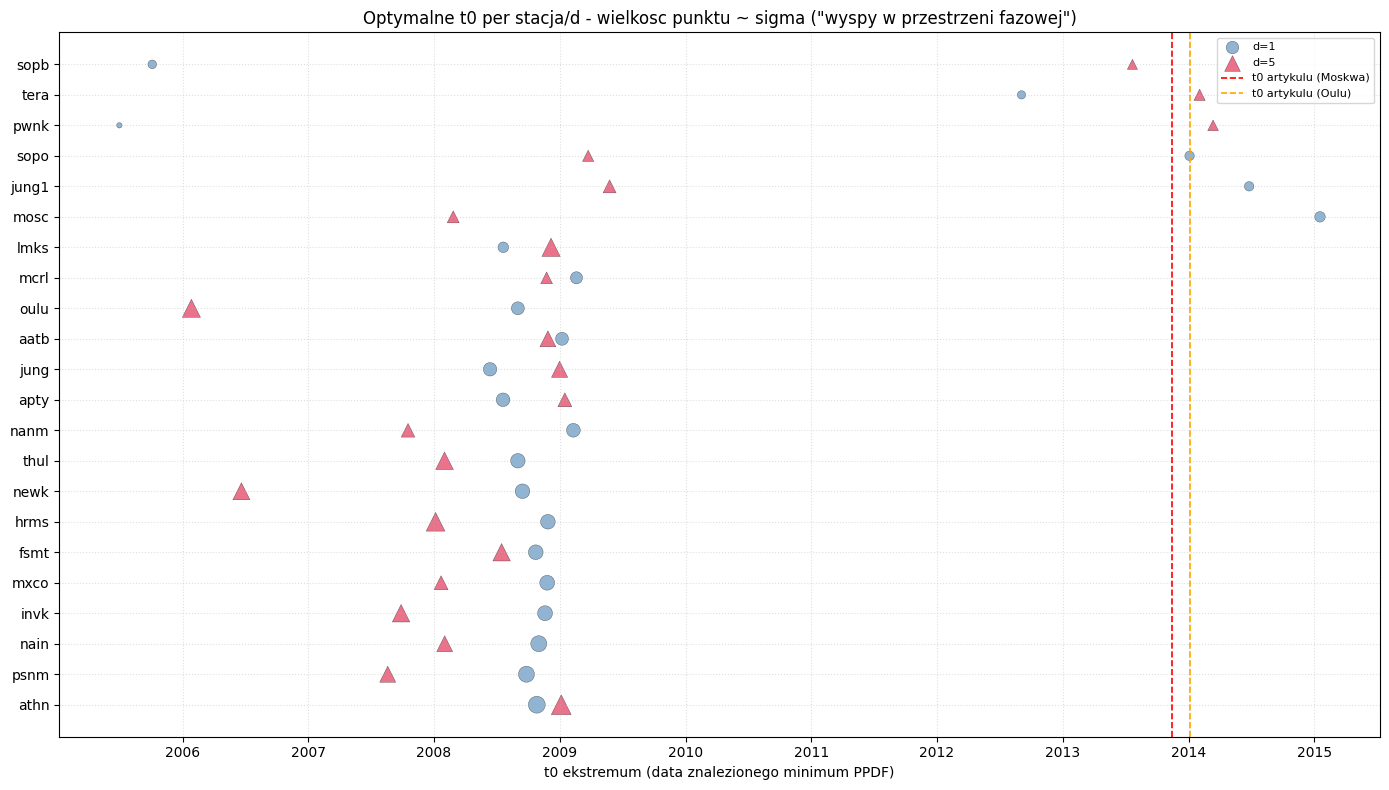

In [9]:
# "Wyspy w przestrzeni fazowej" (Homola, kom. [n]: "...to moze nam dac cos
# nowego (inne wyspy w przestrzeni fazowej dla t0, lagu, szerokosci okna)")
# - ekstrema t0 wszystkich stacji/d na wspolnej osi czasu, wielkosc punktu =
# sigma. Wczytane z zapisanej tabeli podsumowujacej (20260820a.ipynb
# komorka 5), niezaleznie od full_scans powyzej.
summary_saved = pd.read_csv(f"{RESULTS_DIR}/t0_scan_22stations_summary.csv", parse_dates=["t0_best"])

fig, ax = plt.subplots(figsize=(14, 8))
markers = {1: "o", 5: "^"}
colors = {1: "steelblue", 5: "crimson"}
for d in D_VALUES:
    sub = summary_saved[summary_saved["d"] == d].dropna(subset=["t0_best"])
    sizes = np.clip(sub["sigma"], 0, None) ** 2 * 4 + 15
    ax.scatter(sub["t0_best"], sub["station"], s=sizes, marker=markers.get(d, "s"),
               color=colors.get(d, "gray"), alpha=0.6, edgecolor="black", linewidth=0.3, label=f"d={d}")
ax.axvline(ARTICLE_T0_MOSC, color="red", ls="--", lw=1.2, label="t0 artykulu (Moskwa)")
ax.axvline(ARTICLE_T0_OULU, color="orange", ls="--", lw=1.2, label="t0 artykulu (Oulu)")
ax.set_xlabel("t0 ekstremum (data znalezionego minimum PPDF)")
ax.set_title("Optymalne t0 per stacja/d - wielkosc punktu ~ sigma (\"wyspy w przestrzeni fazowej\")")
ax.legend(loc="upper right", fontsize=8)
ax.grid(ls=":", alpha=0.4)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/t0_scan_22stations_phasespace.png", dpi=120)
plt.show()


Kandydaci t0 z -log10(PPDF)>6 w calym skanie: 17295 (z 701492 razem, 2.47%)


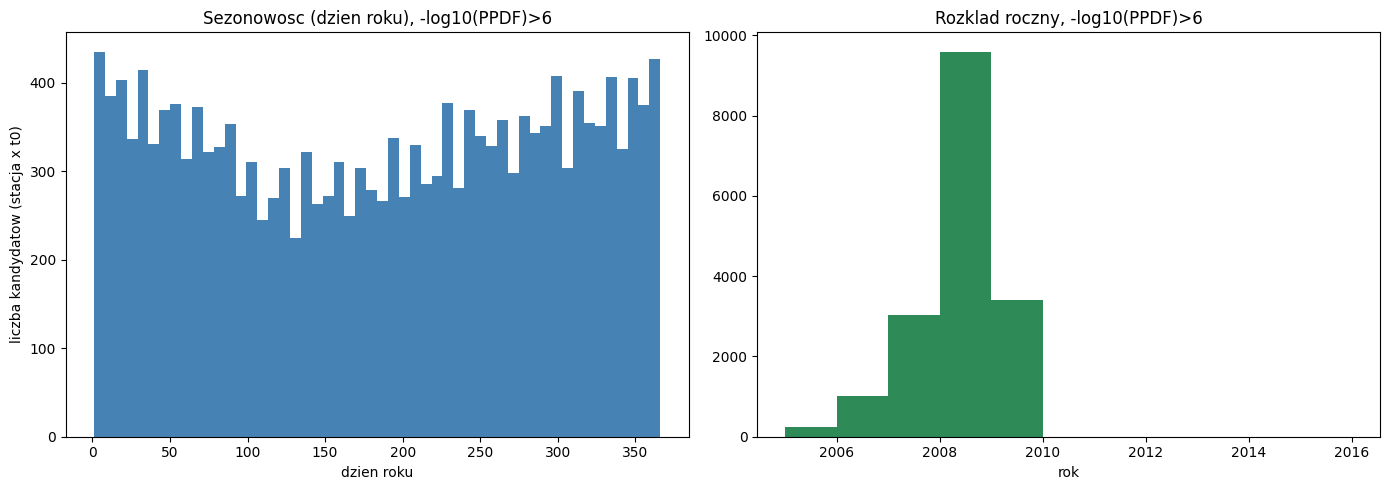

In [10]:
# Test hipotezy sezonowosci Homoli wprost (kom. [u]: "moze w optymalnym t0
# wyszloby cos w rodzaju sezonowosci?"). Zamiast pojedynczego ekstremum per
# stacja, bierzemy WSZYSTKICH kandydatow t0 z silnym efektem
# (-log10(PPDF) > THRESHOLD) z PELNEGO skanu (wszystkie stacje x oba d) i
# patrzymy na ich rozklad wg dnia roku (sezonowosc, w skali <1 roku) ORAZ
# wg roku (klaster wieloletni, w skali cyklu slonecznego - to jest to, co
# juz zauwazylismy jako klaster 2006-2009).
THRESHOLD = 6  # -log10(PPDF) > 6 (~4.5 sigma) - luzniejszy niz benchmark
                # Homoli (-8), celowo: potrzeba wiecej punktow do histogramu

strong_chunks = []
for (station, d), df in full_scans.items():
    ppdf = df["PPDF"].to_numpy()
    with np.errstate(divide="ignore"):
        strength = -np.log10(np.clip(ppdf, 1e-300, None))
    mask = strength > THRESHOLD
    if mask.any():
        strong_chunks.append(pd.DataFrame({
            "t0": df["t0"][mask].to_numpy(), "d": d, "station": station, "strength": strength[mask],
        }))
strong_df = pd.concat(strong_chunks, ignore_index=True) if strong_chunks else pd.DataFrame(columns=["t0", "d", "station", "strength"])
total_points = sum(len(df) for df in full_scans.values())
print(f"Kandydaci t0 z -log10(PPDF)>{THRESHOLD} w calym skanie: {len(strong_df)} (z {total_points} razem, "
      f"{100 * len(strong_df) / total_points:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(pd.to_datetime(strong_df["t0"]).dt.dayofyear, bins=52, color="steelblue")
axes[0].set_xlabel("dzien roku")
axes[0].set_ylabel("liczba kandydatow (stacja x t0)")
axes[0].set_title(f"Sezonowosc (dzien roku), -log10(PPDF)>{THRESHOLD}")
axes[1].hist(pd.to_datetime(strong_df["t0"]).dt.year, bins=range(2005, 2017), color="seagreen")
axes[1].set_xlabel("rok")
axes[1].set_title(f"Rozklad roczny, -log10(PPDF)>{THRESHOLD}")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/t0_scan_seasonality_check.png", dpi=120)
plt.show()
